# 基础流程
1. 理论框架：这个算法解决什么问题
2. 底层逻辑：它到底在优化什么
3. 数学表达：只讲比赛够用的公式
4. sklearn 实践：完整代码
5. 代码解读：每一段为什么这么写
6. 结果解读：指标、图像、模型表现
7. 常见错误：比赛中容易踩的坑
8. 算法标准模板：以后直接放进你的算法文档
9. 作业：巩固当天内容

# 线性回归

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.23

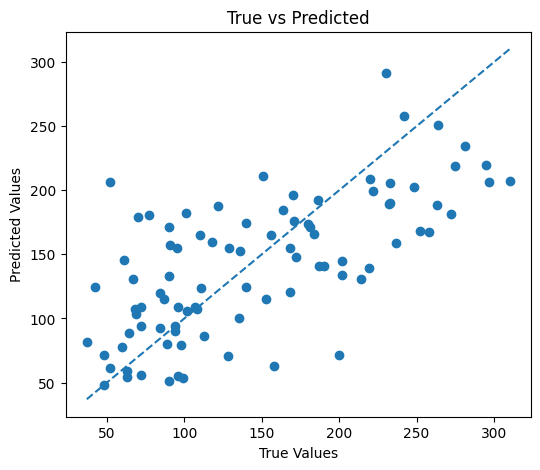

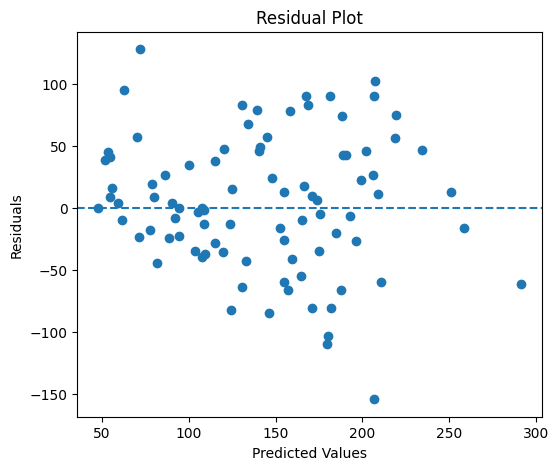

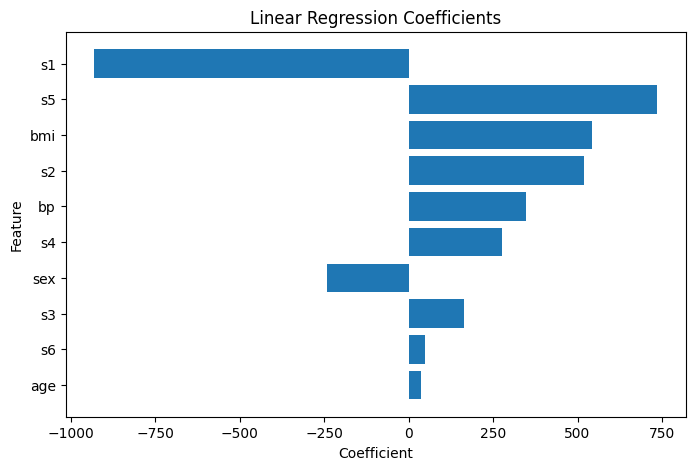

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes #导入数据集
from sklearn.model_selection import train_test_split #导入训练集测试集划分工具
from sklearn.linear_model import LinearRegression #导入线性回归模型
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score #导入评价指标：均方误差MSE，平均绝对误差MAE，R方

#1.加载数据
data=load_diabetes()
X=data.data
y=data.target

print("X shape:",X.shape)
print("y shape:",y.shape)
print("Feature names:",data.feature_names)

#2.转成DataFrame
X_df=pd.DataFrame(X,columns=data.feature_names)
y_series=pd.Series(y,name="target")

df=pd.concat([X_df,y_series],axis=1) #把 X_df 和 y_series 按列拼接起来

print(df.head())
print(df.describe())

#3.划分训练集和测试集
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)

#4.建立并训练模型
model = LinearRegression()

model.fit(X_train, y_train)

#5.查看模型参数
print("Intercept:", model.intercept_) #model.intercept_:截距
print("Coefficients:", model.coef_) #model.coef_:系数

coef_df = pd.DataFrame({
    "feature": data.feature_names,
    "coef": model.coef_
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print(coef_df)

#6.预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#7.计算评价指标
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

print("Train R2:", train_r2)
print("Test R2:", test_r2)


#8.可视化
#图一：真实值vs预测值
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

#完美预测线，斜率为 1 的线
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted")
plt.show()

#图二：残差图
residuals = y_test - y_test_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0, linestyle="--") #画一条 y=0 的水平线

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#图三：系数图
plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coef"]) #barh(y,x):水平条形图
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")
plt.gca().invert_yaxis() #意思是把 y 轴反过来，让排序第一的特征显示在最上面
plt.show()

## 算法名称：线性回归 Linear Regression

一、适用任务
线性回归适用于回归问题，即目标变量为连续数值的预测任务，例如房价预测、销量预测、疾病进展预测、收入预测等。

二、核心思想
线性回归假设目标变量可以由多个特征的线性组合近似表示。模型通过学习各个特征对应的系数和截距，建立从特征 X 到目标 y 的映射关系。

三、数学形式
预测函数：
ŷ = w1x1 + w2x2 + ... + wpxp + b

其中，ŷ 为预测值，x1 至 xp 为特征，w1 至 wp 为特征系数，b 为截距。

四、优化目标
线性回归通过最小化真实值与预测值之间的残差平方和来估计参数：
min Σ(yi - ŷi)²

五、sklearn 实现
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

六、常用评价指标
MSE：平均平方误差，对大误差更敏感。
RMSE：均方根误差，与目标变量单位一致，更容易解释。
MAE：平均绝对误差，直观且对异常值不如 MSE 敏感。
R²：决定系数，用于衡量模型对目标变量波动的解释程度，最高为 1，也可能小于 0。

七、关键可视化
1. 真实值 vs 预测值图：观察预测结果是否接近理想 y=x 直线。
2. 残差图：观察残差是否随机分布在 0 附近，判断模型是否存在系统性误差。
3. 系数图：观察不同特征在线性模型中的方向和相对影响大小。

八、优点
1. 模型简单，训练速度快。
2. 可解释性强，适合作为 baseline。
3. 适合特征与目标近似线性关系的数据。
4. 便于分析特征与目标之间的预测关联。

九、缺点
1. 表达能力有限，难以刻画复杂非线性关系。
2. 对异常值较敏感。
3. 存在多重共线性时，系数可能不稳定。
4. 如果特征量纲不同，直接比较系数大小可能误导。

十、比赛使用建议
在线性回归用于比赛建模时，通常将其作为 baseline 模型。若线性回归表现较差，可以进一步尝试 Ridge、Lasso、决策树、随机森林、GBDT 等模型。报告中应同时展示训练集和测试集指标，并结合真实值-预测值图和残差图分析模型表现。解释系数时应谨慎，不能直接将预测关联解释为因果关系。

今天我完成了 diabetes 数据集上的线性回归建模。该任务属于回归问题，目标是根据 10 个特征预测疾病进展指标。线性回归假设目标变量可以由特征的线性组合近似表示，并通过最小化残差平方和学习模型的系数和截距。模型在训练集上的 RMSE 为 53.56，测试集上的 RMSE 为 53.85；训练集 R² 为 0.528，测试集 R² 为 0.453。结果说明模型没有明显过拟合，但整体预测能力一般，只能解释测试集中约 45.3% 的目标变量波动。True vs Predicted 图显示，散点整体沿 y=x 方向分布，但离虚线较分散，且模型对高真实值样本存在低估倾向。残差图显示残差大致围绕 0 分布，但存在少数大误差点。总体来看，线性回归适合作为 baseline，优点是简单、可解释，缺点是表达能力有限，对非线性关系和异常点较敏感。下一步可以学习 Ridge 和 Lasso，通过正则化提高模型稳定性和泛化能力。